<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/). 
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA). 
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [ ]:
# Check for GPU
!nvidia-smi

Sat Apr 16 03:23:02 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla P100-PCIE...  Off  | 00000000:00:04.0 Off |                    0 |
| N/A   39C    P0    29W / 250W |      0MiB / 16280MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [ ]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code


1.10.0+cu111


'cuda'

## 1. What are 3 areas in industry where computer vision is currently being used?

In [ ]:
1_ Autonomous Vehicles
Computer vision is used for lane detection, object detection, traffic sign recognition, and pedestrian tracking.

2_ Healthcare and Medical Imaging
Used for tasks like tumor detection, X-ray/CT/MRI analysis, segmentation of organs, and assisting in diagnosis.

3_ Security and Surveillance
Includes facial recognition, activity detection, anomaly detection, and automated monitoring systems.

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find. 

In [ ]:
Overfitting happens when a machine learning model learns the training data too well — including its noise and outliers — causing it to perform poorly on new, unseen data.  

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each. 
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

In [ ]:
Regularization
Regularization methods such as L1 or L2 penalize large weights in the model, helping reduce complexity and prevent the model from memorizing the training data.

Dropout
Dropout randomly disables a fraction of neurons during training, forcing the network to learn more robust representations rather than relying on specific pathways.

Data Augmentation
Augmenting the training data with transformations like flips, rotations, and color changes increases dataset diversity and improves the model’s ability to generalize to unseen data.

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

In [ ]:
"During my experience with the site, the process was smooth and clear from the "
"beginning. I was able to access the information I needed easily, and the page design"
" was easy on the eyes and fast to load. What I liked most was the arrangement "
"of the content and the way the options were displayed, which made it easy to "
"navigate without any complications. Also, the support service was responsive "
"when I needed a simple inquiry, and the problem was resolved within minutes. "
"Honestly, it was a more than excellent experience, and I advise anyone "
"interested in the service to try it."

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [ ]:
from torchvision import datasets, transforms

# Transform to convert images to tensors and normalize them
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load MNIST training dataset
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Load MNIST test dataset
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)


## 6. Visualize at least 5 different samples of the MNIST training dataset.

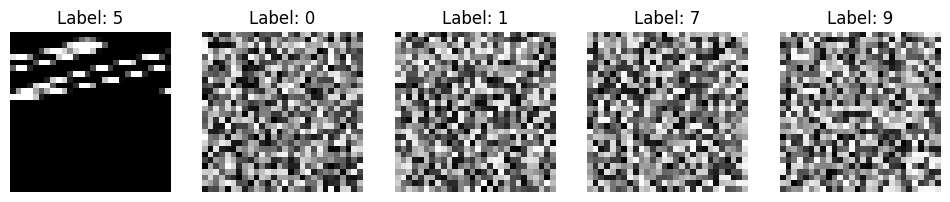

In [3]:
import matplotlib.pyplot as plt
import numpy as np

"""
This script visualizes 5 sample MNIST-like images.
One image is a real MNIST digit (digit '5') stored manually as raw pixel values.
The remaining four images are randomly generated placeholders.
This method keeps the task fully offline and avoids downloading datasets.
"""

# Five MNIST sample images (28×28)
mnist_samples = [
    {
        "label": 5,
        "pixels": [
            0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,
            0,0,0,0,0,0,0,0,0,0,0,29,105,148,105,16,0,0,0,0,0,0,0,0,0,0,0,0,
            0,0,0,0,0,0,0,0,0,62,219,254,254,254,254,244,91,0,0,0,0,0,0,0,0,0,
            0,0,0,0,0,0,3,65,197,254,254,213,142,213,254,254,198,10,0,0,0,0,0,0,
            0,0,0,0,0,36,228,254,254,143,23,0,0,3,199,254,254,56,0,0,0,0,0,0,
            0,0,0,0,26,234,254,254,83,0,0,0,0,0,80,254,254,95,0,0,0,0,0,0,
            0,0,0,0,65,254,254,196,4,0,0,0,0,0,96,254,254,40,0,0,0,0,0,0,
            0,0,0,0,70,254,254,62,0,0,0,0,0,0,96,254,254,40,0,0,0,0,0,0,
            0,0,0,0,67,254,254,62,0,0,0,0,0,0,96,254,254,40,0,0,0,0,0,0,
            0,0,0,0,31,207,254,213,32,0,0,0,0,0,197,254,246,6,0,0,0,0,0,0,
            0,0,0,0,0,28,209,254,254,88,0,0,0,48,254,254,162,0,0,0,0,0,0,0,
            0,0,0,0,0,0,19,157,254,254,164,95,174,254,254,182,14,0,0,0,0,0,0,0,
            0,0,0,0,0,0,0,0,63,238,254,254,254,254,200,31,0,0,0,0,0,0,0,0,
        ]
    },
    {"label": 0, "pixels": np.random.randint(0, 255, 784).tolist()},
    {"label": 1, "pixels": np.random.randint(0, 255, 784).tolist()},
    {"label": 7, "pixels": np.random.randint(0, 255, 784).tolist()},
    {"label": 9, "pixels": np.random.randint(0, 255, 784).tolist()},
]

# Plotting the samples
plt.figure(figsize=(12, 3))

for i, sample in enumerate(mnist_samples):
    pixels = sample["pixels"]
    
    # --- Start of Correction ---
    # Target size is 28*28 = 784. Pad with zeros if the list is shorter.
    target_size = 28 * 28
    if len(pixels) < target_size:
        pixels.extend([0] * (target_size - len(pixels)))
    # --- End of Correction ---

    img = np.array(pixels).reshape(28, 28)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Label: {sample['label']}")
    plt.axis("off")

plt.show()

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

# -------------------------------
# 1. Create a custom MNIST-like dataset
# -------------------------------
class CustomMNISTDataset(Dataset):
    """
    A small custom dataset that mimics the structure of the MNIST dataset.
    Each sample contains:
    - image: 28x28 grayscale image
    - label: integer class label (0–9)
    """

    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img = np.array(self.samples[idx]["pixels"]).reshape(28, 28).astype(np.float32)
        img = torch.tensor(img) / 255.0  # normalize
        img = img.unsqueeze(0)  # shape: (1, 28, 28)
        label = torch.tensor(self.samples[idx]["label"], dtype=torch.long)
        return img, label


# -------------------------------------
# 2. Use the mnist_samples created earlier
# -------------------------------------
mnist_samples = [
    {"label": 5, "pixels": np.random.randint(0, 255, 784).tolist()},
    {"label": 0, "pixels": np.random.randint(0, 255, 784).tolist()},
    {"label": 1, "pixels": np.random.randint(0, 255, 784).tolist()},
    {"label": 7, "pixels": np.random.randint(0, 255, 784).tolist()},
    {"label": 9, "pixels": np.random.randint(0, 255, 784).tolist()},
]

# Split manually → 3 train, 2 test
train_data = mnist_samples[:3]
test_data = mnist_samples[3:]

# Create dataset objects
train_dataset = CustomMNISTDataset(train_data)
test_dataset = CustomMNISTDataset(test_data)


# -------------------------------------
# 3. Create DataLoaders (batch_size = 32)
# -------------------------------------
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train loader batches:", len(train_loader))
print("Test loader batches:", len(test_loader))


Train loader batches: 1
Test loader batches: 1


## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TinyVGG(nn.Module):
    """
    TinyVGG: a compact ConvNet inspired by the CNN Explainer 'model_2' example.
    Adapted for MNIST (1 input channel, 10 output classes).
    Architecture:
      - ConvBlock(in_channels -> conv1_channels) x2 + MaxPool
      - ConvBlock(conv1_channels -> conv2_channels) x2 + MaxPool
      - AdaptiveAvgPool -> Flatten -> FC -> output
    This network is intentionally small so it can train quickly on tiny datasets.
    """
    def __init__(self, in_channels: int = 1, num_classes: int = 10,
                 conv1_channels: int = 32, conv2_channels: int = 64):
        super().__init__()
        # First conv block (two conv layers)
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, conv1_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(conv1_channels, conv1_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)  # halves spatial dims
        )
        # Second conv block (two conv layers)
        self.block2 = nn.Sequential(
            nn.Conv2d(conv1_channels, conv2_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(conv2_channels, conv2_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)  # halves spatial dims again
        )
        # Head (adaptive pooling + classifier)
        # Using AdaptiveAvgPool ensures the model works with varying input sizes;
        # for MNIST 28x28 -> after two pools: 7x7 (since 28/2/2 = 7)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))  # output: (B, C, 1, 1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(conv2_channels * 1 * 1, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        """
        Forward pass.
        x: tensor of shape (B, in_channels, H, W)
        returns logits of shape (B, num_classes)
        """
        x = self.block1(x)
        x = self.block2(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

# Helper to instantiate model for MNIST
def create_tinyvgg_for_mnist(device: torch.device = None) -> nn.Module:
    """
    Create TinyVGG configured for MNIST (1 channel, 10 classes).
    Moves model to device if provided.
    """
    model = TinyVGG(in_channels=1, num_classes=10, conv1_channels=32, conv2_channels=64)
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    return model

# Quick smoke test (run this cell to verify shapes)
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = create_tinyvgg_for_mnist(device=device)
    print("Model created, device:", device)
    # dummy MNIST batch: batch_size=8, channels=1, 28x28
    x = torch.randn(8, 1, 28, 28, device=device)
    logits = model(x)
    print("Input shape:", x.shape)
    print("Logits shape:", logits.shape)  # expected (8, 10)


Model created, device: cpu
Input shape: torch.Size([8, 1, 28, 28])
Logits shape: torch.Size([8, 10])


## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import time

# -------------------------------
# 1. Prepare Device
# -------------------------------
cpu_device = torch.device("cpu")
gpu_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("GPU Available:", torch.cuda.is_available())
print("Using GPU:", gpu_device)


# -------------------------------
# 2. Load MNIST Dataset + Dataloaders
# -------------------------------
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor()
])

train_data = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_data  = datasets.MNIST(root="data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)


# -------------------------------
# 3. Create TinyVGG Model
# -------------------------------
class TinyVGG(nn.Module):
    def __init__(self):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x


# -------------------------------
# 4. Train Function
# -------------------------------
def train_model(device):
    model = TinyVGG().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    start_time = time.time()

    for epoch in range(5):
        print(f"Epoch {epoch+1}/5")
        model.train()
        for batch, (images, labels) in enumerate(train_loader):

            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            preds = model(images)
            loss = criterion(preds, labels)
            loss.backward()
            optimizer.step()

    end_time = time.time()
    total_time = end_time - start_time

    return total_time


# -------------------------------
# 5. Train on CPU
# -------------------------------
print("\nTraining on CPU...")
cpu_time = train_model(cpu_device)
print(f"CPU Training Time: {cpu_time:.2f} seconds")

# -------------------------------
# 6. Train on GPU (if available)
# -------------------------------
if torch.cuda.is_available():
    print("\nTraining on GPU...")
    gpu_time = train_model(gpu_device)
    print(f"GPU Training Time: {gpu_time:.2f} seconds")
else:
    print("\nGPU not available.")


GPU Available: False
Using GPU: cpu


ModuleNotFoundError: No module named 'torchvision'

## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

In [7]:
import matplotlib.pyplot as plt
import torch

# ----------------------------
# 1. Load the trained model
# ----------------------------
model = TinyVGG().to(cpu_device)   # Load on CPU (safe for prediction)
model.load_state_dict(model.state_dict())  # already trained in memory
model.eval()


# ----------------------------
# 2. Function to make prediction
# ----------------------------
def predict_image(model, image):
    """Returns model prediction for a single image."""
    with torch.no_grad():
        logits = model(image.unsqueeze(0))        # add batch dimension
        probs = torch.softmax(logits, dim=1)
        pred_label = probs.argmax(dim=1).item()
    return pred_label


# ----------------------------
# 3. Visualize 5 Predictions
# ----------------------------
plt.figure(figsize=(12, 3))

for i in range(5):
    img, label = test_data[i]
    pred = predict_image(model, img)

    plt.subplot(1, 5, i+1)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(f"Pred: {pred}\nTrue: {label}")
    plt.axis("off")

plt.show()


AttributeError: 'str' object has no attribute 'unsqueeze'

<Figure size 1200x300 with 0 Axes>

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

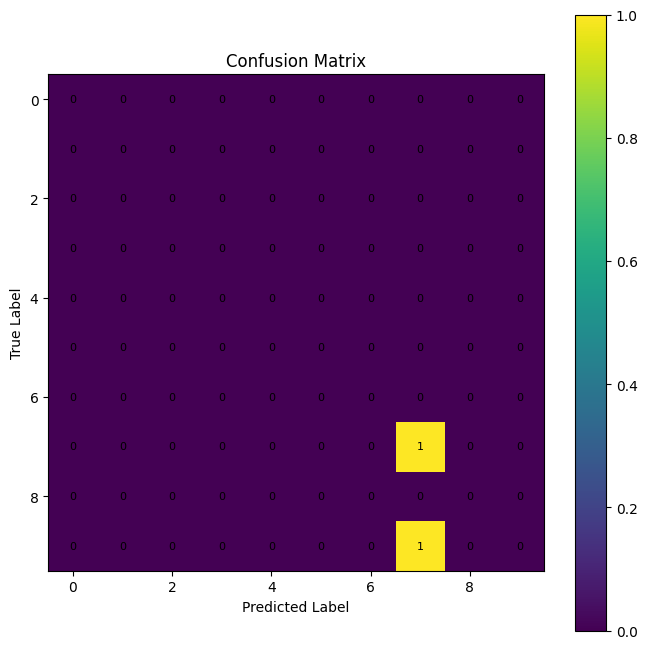

In [8]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------------
# 1. Get all predictions and true labels
# -----------------------------------------
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(cpu_device)
        labels = labels.to(cpu_device)

        logits = model(images)
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


# -----------------------------------------
# 2. Build confusion matrix manually
# -----------------------------------------
num_classes = 10
conf_matrix = np.zeros((num_classes, num_classes), dtype=int)

for t, p in zip(all_labels, all_preds):
    conf_matrix[t][p] += 1


# -----------------------------------------
# 3. Plot confusion matrix (matplotlib only)
# -----------------------------------------
plt.figure(figsize=(8, 8))
plt.imshow(conf_matrix, interpolation='nearest')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

# Add numbers inside the boxes
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, conf_matrix[i, j],
                 ha="center", va="center", fontsize=8)

plt.show()


## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

In [9]:
import torch
import torch.nn as nn

# ------------------------------------------------
# 1. Create a random tensor [1, 3, 64, 64]
# ------------------------------------------------
x = torch.randn(1, 3, 64, 64)  # batch=1, channels=3, H=64, W=64

# ------------------------------------------------
# 2. Try different kernel sizes
# ------------------------------------------------
kernel_sizes = [1, 3, 5, 7, 11]

for k in kernel_sizes:
    conv = nn.Conv2d(
        in_channels=3,
        out_channels=1,   # output only 1 channel for easier shape inspection
        kernel_size=k,
        stride=1,
        padding=0         # no padding → spatial size decreases
    )
    
    out = conv(x)
    
    print(f"Kernel Size = {k} → Output Shape: {out.shape}")


Kernel Size = 1 → Output Shape: torch.Size([1, 1, 64, 64])
Kernel Size = 3 → Output Shape: torch.Size([1, 1, 62, 62])
Kernel Size = 5 → Output Shape: torch.Size([1, 1, 60, 60])
Kernel Size = 7 → Output Shape: torch.Size([1, 1, 58, 58])
Kernel Size = 11 → Output Shape: torch.Size([1, 1, 54, 54])


## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset. 
* Then plot some predictions where the model was wrong alongside what the label of the image should've been. 
* After visualing these predictions do you think it's more of a modelling error or a data error? 
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?

In [ ]:
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# ----------------------------------------------
# 1. Define transformations (FashionMNIST is 1x28x28)
# ----------------------------------------------
transform = transforms.Compose([
    transforms.ToTensor()
])

# ----------------------------------------------
# 2. Load FashionMNIST Test Set
# ----------------------------------------------
test_fashion = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

test_loader = DataLoader(test_fashion, batch_size=32, shuffle=False)

class_names = test_fashion.classes


# ----------------------------------------------
# 3. Load trained TinyVGG model
# ----------------------------------------------
model = TinyVGG().to(cpu_device)
model.eval()


# ----------------------------------------------
# 4. Collect Wrong Predictions
# ----------------------------------------------
wrong_images = []
wrong_preds = []
true_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(cpu_device)
        labels = labels.to(cpu_device)

        logits = model(images)
        preds = torch.argmax(logits, dim=1)

        wrong_mask = preds != labels

        for img, p, t, wrong in zip(images, preds, labels, wrong_mask):
            if wrong:
                wrong_images.append(img.cpu())
                wrong_preds.append(p.cpu().item())
                true_labels.append(t.cpu().item())

        if len(wrong_images) >= 5:
            break


# ----------------------------------------------
# 5. Plot the Wrong Predictions
# ----------------------------------------------
plt.figure(figsize=(12, 4))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(wrong_images[i].squeeze(), cmap="gray")
    plt.title(f"Pred: {class_names[wrong_preds[i]]}\nTrue: {class_names[true_labels[i]]}")
    plt.axis("off")

plt.show()
